<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul6/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
def convolution2d(image, kernel, stride=1, padding=0):
  # Pastikan citra masukan berupa NumPy array
  image = np.array(image, dtype=float)
  kernel = np.array(kernel, dtype=float)

  # Rotasi kernel 180 derajat untuk operasi konvolusi sesungguhnya
  kernel = np.flipud(np.fliplr(kernel))

  # Dimensi citra dan kernel
  img_height, img_width = image.shape[:2]
  kernel_height, kernel_width = kernel.shape[:2]

  # Menambahkan padding (zero padding) jika dispesifikasikan
  if padding > 0:
    padded_image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
  else:
    padded_image = image

  # Dimensi citra setelah padding
  padded_height, padded_width = padded_image.shape[:2]

  # Menghitung dimensi output
  out_height = int((padded_height - kernel_height) / stride) + 1
  out_width = int((padded_width - kernel_width) / stride) + 1

  # Inisialisasi output image
  output = np.zeros((out_height, out_width))

  # Melakukan operasi konvolusi
  for y in range(0, out_height):
    for x in range(0, out_width):
      # Mengambil region of interest (ROI)
      y_start = y * stride
      y_end = y_start + kernel_height
      x_start = x * stride
      x_end = x_start + kernel_width

      roi = padded_image[y_start:y_end, x_start:x_end]

      # Element-wise multiplication dan penjumlahan
      output[y, x] = np.sum(roi * kernel)

  return output

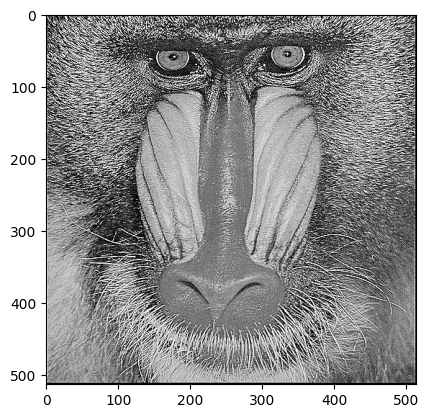

In [41]:
img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# kernel sharpening
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_sharpen_uint8 = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_sharpen_uint8, cv.COLOR_GRAY2RGB))
plt.show()

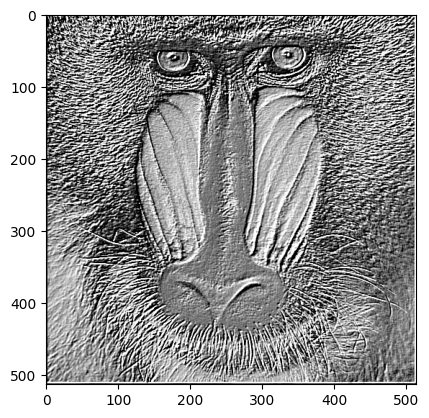

In [42]:

# kernel emboss
kernel_emboss = np.array([[-2,-1,0],
                           [-1,1,1],
                           [0,1,2]])
hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_emboss_uint8 = np.clip(hasil_emboss, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_emboss_uint8, cv.COLOR_GRAY2RGB))
plt.show()

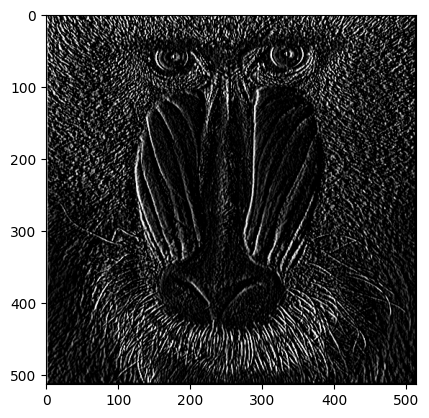

In [43]:

# kernel LeftSobelEdge
kernel_LeftSobelEdge = np.array([[1,0,-1],
                           [2,0,-2],
                           [1,0,-1]])
hasil_LeftSobelEdge = convolution2d(img_gray, kernel_LeftSobelEdge, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_LeftSobelEdge_uint8 = np.clip(hasil_LeftSobelEdge, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_LeftSobelEdge_uint8, cv.COLOR_GRAY2RGB))
plt.show()

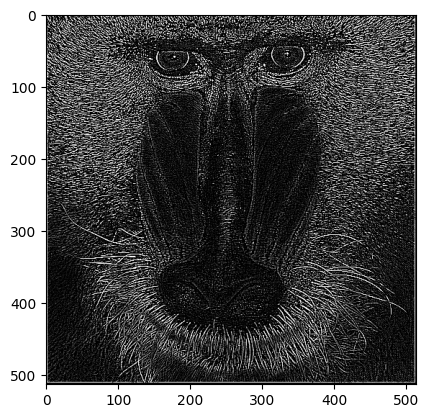

In [44]:

# kernel CannyEdge
kernel_CannyEdge = np.array([[-1,-1,-1],
                           [-1,8,-1],
                           [-1,-1,-1]])
hasil_CannyEdge = convolution2d(img_gray, kernel_CannyEdge, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_CannyEdge_uint8 = np.clip(hasil_CannyEdge, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_CannyEdge_uint8, cv.COLOR_GRAY2RGB))
plt.show()

In [45]:
kernel_size = 21

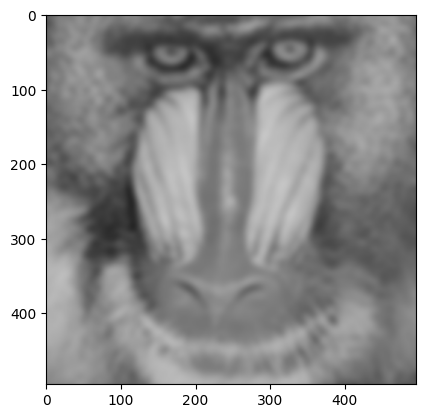

In [46]:
# gaussian kernel
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gauss = gaussian_kernel @ gaussian_kernel.transpose()

hasil_gauss = convolution2d(img_gray, kernel_gauss, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_gauss_uint8 = np.clip(hasil_gauss, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_gauss_uint8, cv.COLOR_GRAY2RGB))
plt.show()

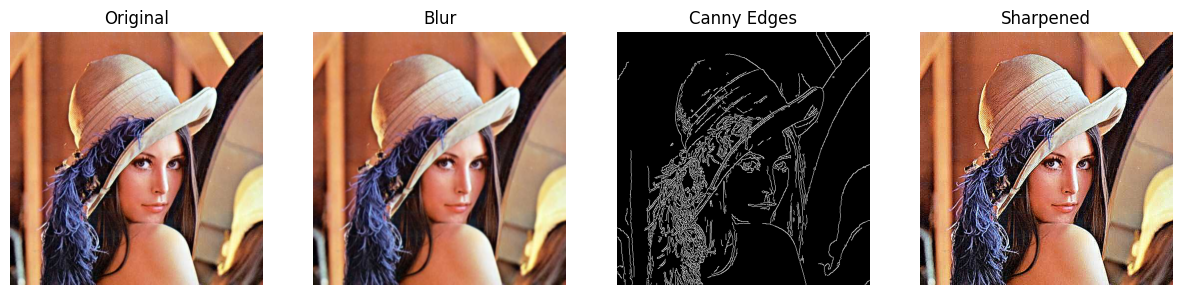

In [47]:
# fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2: #grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5, -1], [0,-1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, edges, sharpened], ['Original', 'Blur', 'Canny Edges', 'Sharpened'])

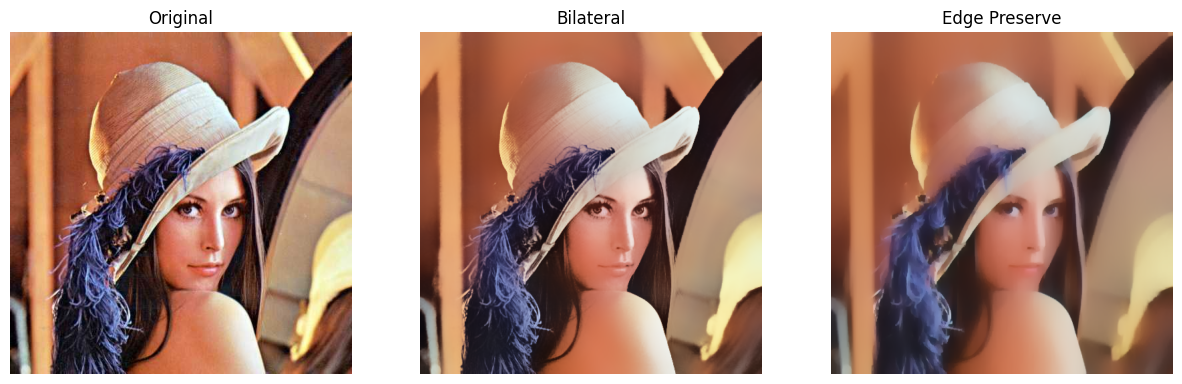

In [38]:
# filter modern dari open cv
# bilateral filter edge preserving
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# edge preserving filter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Original', 'Bilateral', 'Edge Preserve'])

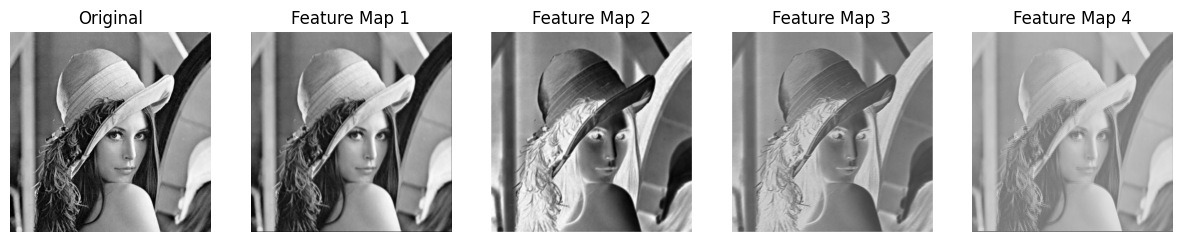

In [49]:
# filter feature map yg digunakan di CNN
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
      return self.conv1(x)

model = SimpleCNN()

# ubahb gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0)/255.0

# hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Original'] + [f'Feature Map {i+1}' for i in range(len(feature_maps))])

In [ ]:
# beauty filter
# step 1 smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# step 2 unsharp masking pertajam mata/bibir
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# step 3 brightness dan contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# old / vintage filter
# step 1 sephia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# step 2 Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3);
  vignette[:,:,i] = vignette[:,:,i]*mask

# step 3 noise/grain
noise = np.random.normal(0,15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16)+noise, 0, 255).astype(np.uint8)
show_side_by_side([img, beauty, old_img], ['ori', 'beauty', 'old'])

In [ ]:
# filter anime cartoon
# step 1 edge detection pakai medium blur agar gambar menjadi halus
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blue, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9,9)

# step 2 bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor = 200, sigmaSpace=200)
# step3 gabungkan cartoonize
cartoon = cv.bitwise_and(color, color, mask=edges)

# tampilkan
show_side_by_side([img, cartoon], ['asli', 'kartun filter'])